Thư viện

In [98]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split # Chia dữ liệu thành tập huấn luyện và tập kiểm tra
from sklearn.preprocessing import StandardScaler # Chuẩn hóa dữ liệu
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve

Đọc file đặc trưng

In [108]:
data = pd.read_csv('features.csv')

Tách features(x) và label(y)

In [57]:
X = data.drop('label', axis=1) # axis 1 để chỉ cột
y = data['label'] # Lấy cột label

Chia dữ liệu thành tập huấn luyện và tập kiểm tra

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20% dữ liệu dùng để kiểm tra

Chuẩn hóa dữ liệu

In [59]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train) # Chuẩn hóa dữ liệu huấn luyện
X_test_scale = scaler.transform(X_test) # Chuẩn hóa dữ liệu kiểm tra


Tạo mô hình hồi quy logistic

In [99]:
Model = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, random_state=42, max_iter=200, n_jobs=-1)

Learning curve

In [105]:
train_sizes, train_scores, test_scores = learning_curve(
    Model, X, y, cv=5, scoring='accuracy', n_jobs=-1
) 
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

Huấn luyện mô hình

In [100]:
Model.fit(X_train_scale, y_train) # Huấn luyện mô hình

LogisticRegression(max_iter=200, n_jobs=-1, random_state=42)

Dự đoán

In [101]:
train_predict = Model.predict(X_train_scale)
test_predict = Model.predict(X_test_scale)

Đánh giá mô hình

In [102]:
# Confusion Matrix
train_cm = confusion_matrix(y_train, train_predict)
test_cm = confusion_matrix(y_test, test_predict)
# Accuracy
train_accuracy = accuracy_score(y_train, train_predict)
test_accuracy = accuracy_score(y_test, test_predict)

Biểu đồ confusion matrix

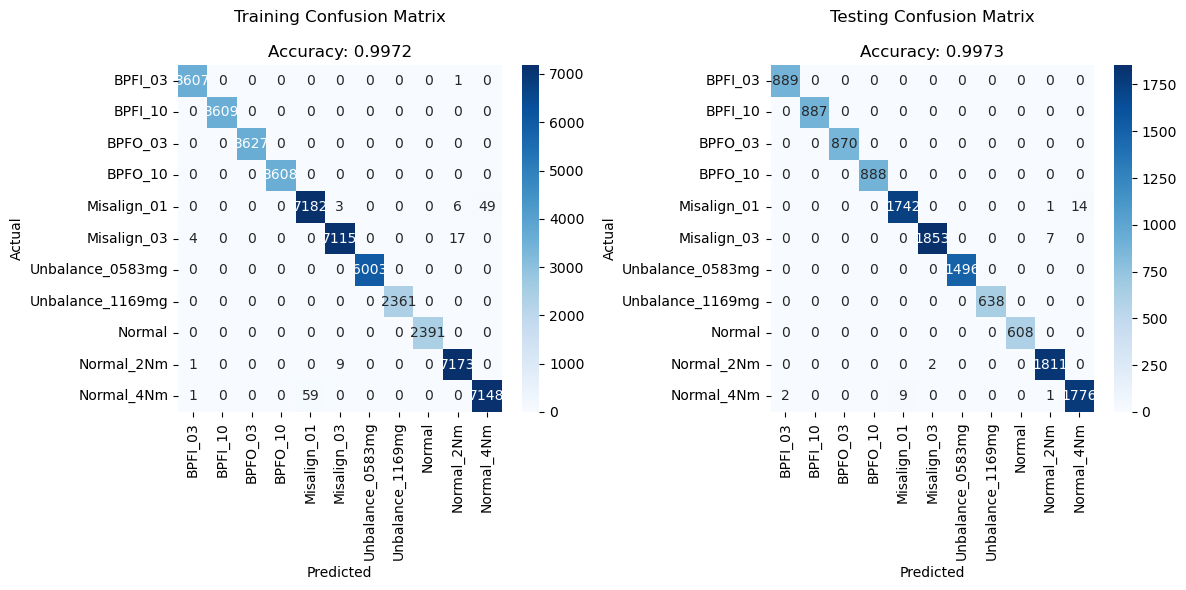

In [109]:
#Các loại lỗi
Fault_types = [ 'BPFI_03',
                'BPFI_10', 
                'BPFO_03', 
                'BPFO_10', 
                'Misalign_01', 
                'Misalign_03',
                'Unbalance_0583mg',
                'Unbalance_1169mg',
                'Normal',
                'Normal_2Nm',
                'Normal_4Nm',
                ]      
#Biểu đồ confusion matrix
plt.figure(figsize=(12, 6))# Kích thước biểu đồ
plt.subplot(1, 2, 1)# Vẽ biểu đồ đầu tiên trong 1 hàng 2 cột
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', 
xticklabels=Fault_types, yticklabels=Fault_types)# Vẽ heatmap với các nhãn trục x và y
plt.title(f'Training Confusion Matrix\n\nAccuracy: {train_accuracy:.4f}')# Tiêu đề biểu đồ
plt.xlabel('Predicted')# Nhãn trục x
plt.ylabel('Actual')# Nhãn trục y
plt.subplot(1, 2, 2)# Vẽ biểu đồ thứ hai trong 1 hàng 2 cột
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
xticklabels=Fault_types, yticklabels=Fault_types)# Vẽ heatmap với các nhãn trục x và y
plt.title(f'Testing Confusion Matrix\n\nAccuracy: {test_accuracy:.4f}')# Tiêu đề biểu đồ
plt.xlabel('Predicted')# Nhãn trục x
plt.ylabel('Actual')# Nhãn trục y
plt.tight_layout()# Tự động điều chỉnh khoảng cách giữa các phần tử trong biểu đồ
plt.show()# Hiển thị biểu đồ


Biểu đồ learning curve để đánh giá overfit

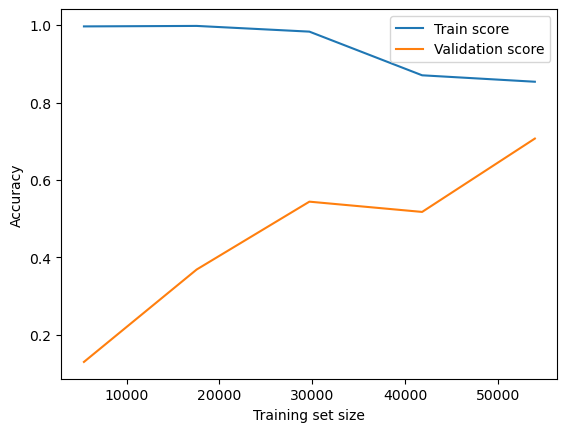

In [106]:
plt.plot(train_sizes, train_scores_mean, label="Train score")
plt.plot(train_sizes, test_scores_mean, label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()